# NEPSE Stock Analysis (merolagani data)

Pulls OHLCV data from merolagani's chart API for one or more NEPSE-listed symbols,
then computes returns, volatility, drawdown, correlation, and simple technical-indicator
backtests.

Note: this hits an unofficial/scraped endpoint — be polite with request frequency
and expect it to occasionally change shape or go down.


In [1]:
import time
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.options.display.float_format = "{:.2f}".format
plt.rcParams["figure.figsize"] = (11, 5)


## Fetch data

`resolution` follows TradingView-UDF style: `1D`, `1W`, `1M`, or intraday minutes like `15`.
`rangeStartDate` / `rangeEndDate` are unix timestamps.


In [2]:
BASE_URL = "https://merolagani.com/handlers/TechnicalChartHandler.ashx"

def fetch_ohlcv(symbol, resolution="1D", start=None, end=None, currency="NPR"):
    """Fetch OHLCV bars for a NEPSE symbol from merolagani's chart API.

    Returns a DataFrame indexed by date with columns open/high/low/close/volume.
    """
    if end is None:
        end = int(time.time())
    if start is None:
        start = end - 5 * 365 * 24 * 3600  # ~5 years back

    params = {
        "type": "get_advanced_chart",
        "symbol": symbol,
        "resolution": resolution,
        "isAdjust": 1,
        "currencyCode": currency,
        "rangeStartDate": start,
        "rangeEndDate": end,
    }
    headers = {"User-Agent": "Mozilla/5.0"}
    resp = requests.get(BASE_URL, params=params, headers=headers, timeout=15)
    resp.raise_for_status()
    data = resp.json()

    status = data.get("s")
    if status != "ok" or not data.get("t"):
        raise ValueError(f"No data returned for {symbol}: {status}")

    df = pd.DataFrame({
        "date": pd.to_datetime(data["t"], unit="s"),
        "open": data["o"],
        "high": data["h"],
        "low": data["l"],
        "close": data["c"],
        "volume": data["v"],
    }).set_index("date").sort_index()
    return df


In [3]:
# Edit this list to whatever symbols make up your portfolio / watchlist
SYMBOLS = ["SOPL"]

RESOLUTION = "1D"  # daily bars

data = {}
for sym in SYMBOLS:
    try:
        data[sym] = fetch_ohlcv(sym, resolution=RESOLUTION)
        print(f"{sym}: {len(data[sym])} bars, {data[sym].index.min().date()} -> {data[sym].index.max().date()}")
    except Exception as e:
        print(f"{sym}: FAILED ({e})")


SOPL: FAILED (name 'fetch_ohlcv' is not defined)


In [4]:
data[SYMBOLS[0]].tail()


KeyError: 'SOPL'

## Price chart

/tmp/ipykernel_78546/1358968980.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


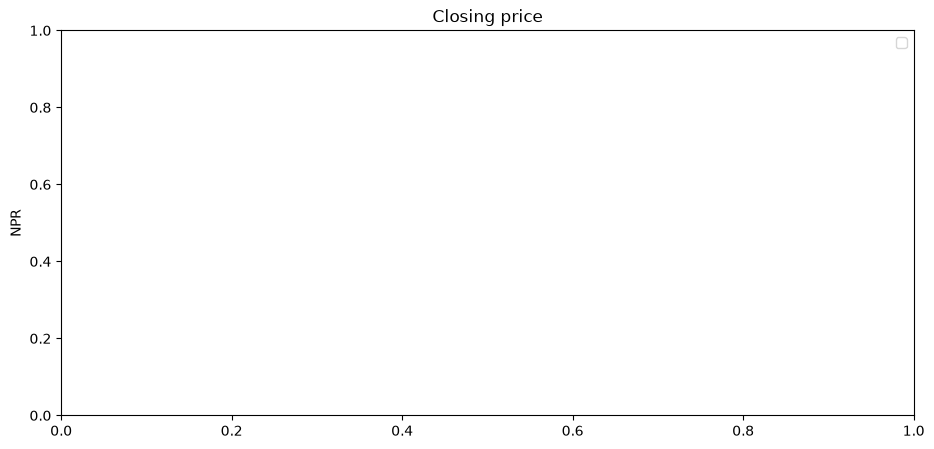

In [5]:
fig, ax = plt.subplots()
for sym, df in data.items():
    ax.plot(df.index, df["close"], label=sym)
ax.set_title("Closing price")
ax.set_ylabel("NPR")
ax.legend()
plt.show()


## Returns & risk metrics

Daily/period returns, annualized volatility, and max drawdown per symbol.


In [6]:
def compute_metrics(df, periods_per_year=252):
    ret = df["close"].pct_change().dropna()
    cum = (1 + ret).cumprod()
    running_max = cum.cummax()
    drawdown = cum / running_max - 1

    total_return = cum.iloc[-1] - 1
    years = (df.index[-1] - df.index[0]).days / 365.25
    cagr = (cum.iloc[-1]) ** (1 / years) - 1 if years > 0 else np.nan
    vol_annual = ret.std() * np.sqrt(periods_per_year)
    sharpe = (ret.mean() * periods_per_year) / vol_annual if vol_annual else np.nan

    return pd.Series({
        "total_return_%": total_return * 100,
        "cagr_%": cagr * 100,
        "ann_volatility_%": vol_annual * 100,
        "sharpe_naive": sharpe,
        "max_drawdown_%": drawdown.min() * 100,
    })

metrics = pd.DataFrame({sym: compute_metrics(df) for sym, df in data.items()}).T
metrics


""


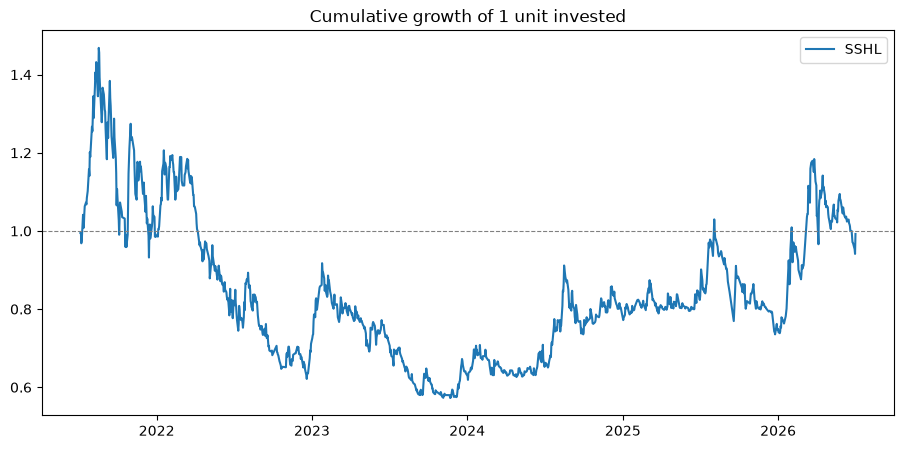

In [7]:
fig, ax = plt.subplots()
for sym, df in data.items():
    ret = df["close"].pct_change().dropna()
    cum = (1 + ret).cumprod()
    ax.plot(cum.index, cum, label=sym)
ax.axhline(1.0, color="gray", linewidth=0.8, linestyle="--")
ax.set_title("Cumulative growth of 1 unit invested")
ax.legend()
plt.show()


## Drawdown chart


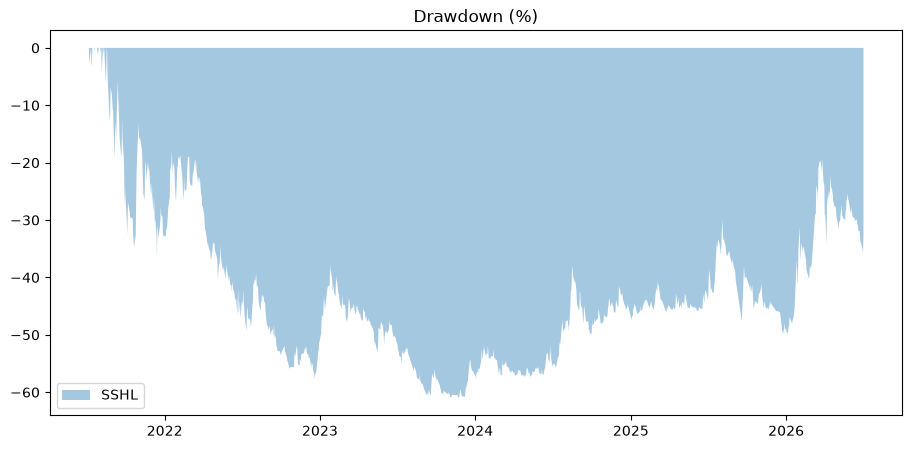

In [8]:
fig, ax = plt.subplots()
for sym, df in data.items():
    ret = df["close"].pct_change().dropna()
    cum = (1 + ret).cumprod()
    drawdown = cum / cum.cummax() - 1
    ax.fill_between(drawdown.index, drawdown * 100, 0, alpha=0.4, label=sym)
ax.set_title("Drawdown (%)")
ax.legend()
plt.show()


## Correlation matrix

Only meaningful once you have 2+ symbols in `SYMBOLS`.


In [9]:
if len(data) > 1:
    close_df = pd.DataFrame({sym: df["close"] for sym, df in data.items()})
    corr = close_df.pct_change().corr()
    display(corr)
else:
    print("Add more symbols to SYMBOLS to see correlation.")


Add more symbols to SYMBOLS to see correlation.


## Portfolio (equal-weight, or set your own weights)

Combines the symbols above into a single portfolio return series.


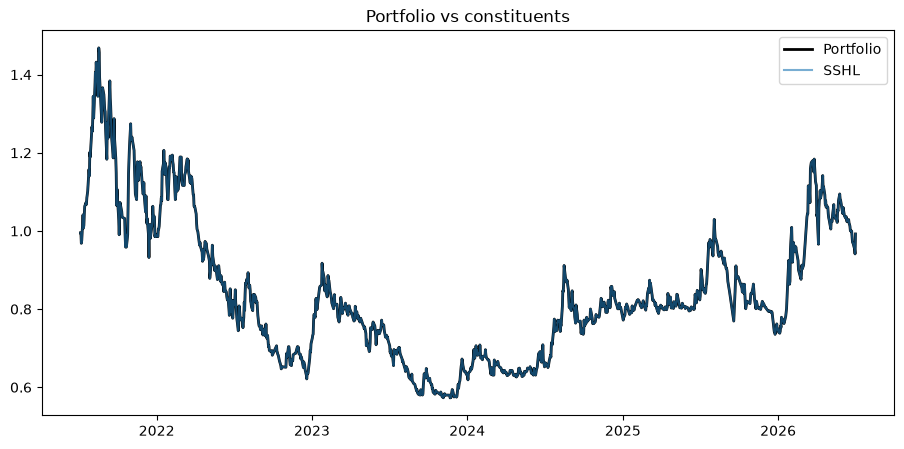

total_return_%      -0.29
cagr_%              -0.06
ann_volatility_%    37.44
sharpe_naive         0.18
max_drawdown_%     -60.99
dtype: float64

In [10]:
# Set weights per symbol; must sum to 1. Defaults to equal-weight.
WEIGHTS = {sym: 1 / len(SYMBOLS) for sym in SYMBOLS}

close_df = pd.DataFrame({sym: df["close"] for sym, df in data.items()}).dropna()
rets = close_df.pct_change().dropna()
port_ret = (rets * pd.Series(WEIGHTS)).sum(axis=1)
port_cum = (1 + port_ret).cumprod()

fig, ax = plt.subplots()
ax.plot(port_cum.index, port_cum, label="Portfolio", linewidth=2, color="black")
for sym in SYMBOLS:
    cum = (1 + rets[sym]).cumprod()
    ax.plot(cum.index, cum, label=sym, alpha=0.6)
ax.legend()
ax.set_title("Portfolio vs constituents")
plt.show()

compute_metrics(pd.DataFrame({"close": port_cum * close_df.iloc[0].mean()}))


## Simple moving-average crossover backtest

This is a *backtest*, not a prediction: it shows how a rule-based strategy would
have performed historically on this symbol. Past performance on a thinly-traded
market like NEPSE is a weak guide to future results — treat this as exploration,
not a forecast.


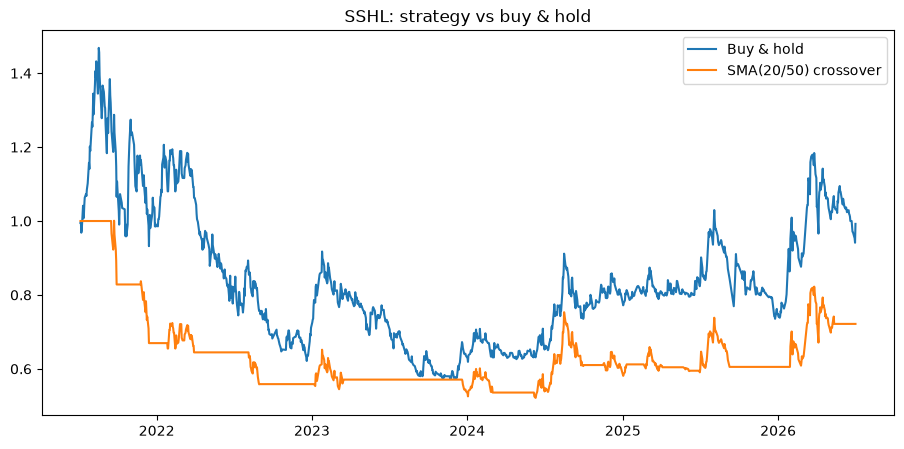

Buy & hold total return: -0.8%
Strategy total return:   -27.8%


In [11]:
def sma_crossover_backtest(df, fast=20, slow=50):
    d = df.copy()
    d["sma_fast"] = d["close"].rolling(fast).mean()
    d["sma_slow"] = d["close"].rolling(slow).mean()
    d["signal"] = (d["sma_fast"] > d["sma_slow"]).astype(int)  # 1 = long, 0 = flat
    d["strategy_ret"] = d["signal"].shift(1) * d["close"].pct_change()
    d["buy_hold_cum"] = (1 + d["close"].pct_change()).cumprod()
    d["strategy_cum"] = (1 + d["strategy_ret"]).cumprod()
    return d

sym0 = SYMBOLS[0]
bt = sma_crossover_backtest(data[sym0])

fig, ax = plt.subplots()
ax.plot(bt.index, bt["buy_hold_cum"], label="Buy & hold")
ax.plot(bt.index, bt["strategy_cum"], label="SMA(20/50) crossover")
ax.legend()
ax.set_title(f"{sym0}: strategy vs buy & hold")
plt.show()

print("Buy & hold total return: {:.1f}%".format((bt["buy_hold_cum"].iloc[-1] - 1) * 100))
print("Strategy total return:   {:.1f}%".format((bt["strategy_cum"].iloc[-1] - 1) * 100))


## Next steps (ideas, not yet built)

- Swap in your real portfolio holdings + weights once you know them
- Pull dividend/bonus adjustment info if you want total-return accuracy beyond `isAdjust`
- Try more resolutions (`1W`, `1M`) to see longer-term trend without daily noise
- If "prediction" is still wanted: frame as scenario/backtest analysis (multiple
  strategies compared) rather than a point forecast, since NEPSE small-caps are
  thin, gappy, and not well suited to statistical forecasting models
